# Tutorial: Graph perturbations with `Cellina`

`Cellina` is a dual-encoder variational autoencoder that separates a cell's **intrinsic** state (its identity, $z$) from its **spatial context** (the influence of its neighbours, $s$). Because the two are disentangled, we can hold a cell's identity fixed and ask *counterfactual* questions about its neighbourhood — a class of queries we call **tissue-graph counterfactuals**.

In this notebook we:
1. Load and pre-process a colorectal cancer (CRC) spatial dataset {cite:p}`crowell2025tracing`
2. Train `Cellina`
3. Visualise the two latent spaces ($z$, $s$) to confirm the disentanglement
4. Run two types of counterfactual interventions (as in silico graph perturbations) on a held-out cancer cell population:
    - **Edge perturbation** — rewire a cell's neighbourhood
    - **Node perturbation** — alter the expression of its neighbours

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scanpy as sc
import torch
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from scvi.train._callbacks import SaveCheckpoint, EarlyStopping
from scipy.stats import pearsonr

from cellina import Cellina, make_neighbor_perturbation
from cellina._spatial_utils import spatial_neighbors, compute_spatial_features

In [3]:
# Fixing seeds and ensuring deterministic behavior for reproducibility
seed = 0
np.random.seed(seed)  # NumPy
torch.manual_seed(seed)  # PyTorch CPU
torch.cuda.manual_seed(seed)  # PyTorch GPU (single-GPU)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 1. Data preprocessing

We use `scanpy` {cite:p}`wolf2018scanpy` for loading, QC, normalisation, and the UMAP visualisations below.

### Load adata and preprocess

In [4]:
adata = sc.read(
    f"./data/crc_232.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/232.h5ad?download=1"
)
adata.obs_names_make_unique()

For the CRC data, we define a custom celltype label map which groups together major cell types - needed as e.g. epi1-4 correspond to different epithelial subtypes found in healthy and diseased tissues.

In [5]:
label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",

    "fib1": "Fibroblast",
    "fib2": "Fibroblast",

    "EC": "Endothelial",
    "SMC": "Smooth_muscle",

    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",

    "TC": "T_cell",

    "mye1": "Myeloid",
    "mye2": "Myeloid",

    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)

In [6]:
# Set annotation keys
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = None

In [7]:
# Filtering and QC
adata = adata[~adata.obs[domains_key].isna()]
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [8]:
# HVG selection
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

### Data splits

For this demo, we will holdout Myeloid cells in the cancer (CRC) region

In [9]:
holdout_ct = 'Myeloid'
is_tumor_region  = adata.obs[domains_key].str.contains("CRC", regex=True)
is_holdout_ct = adata.obs[labels_key] == holdout_ct

# Combine for test set
test_mask = (is_tumor_region) & (is_holdout_ct)
test_idx = np.where(test_mask)[0]

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [10]:
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [11]:
validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [12]:
print("Train size:", len(train_idx))
print("Validation size:", len(val_idx))
print("Test size:", len(test_idx))

Train size: 96258
Validation size: 10696
Test size: 5035


### Spatial features preprocessing

As we are performing an out-of-distribution inference on CRC Myeloids, we want to keep them out when computing adjacency and spatial feature aggregation. We store original adjacency structure for inference.

In [13]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

max_neighbors = 200
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.obsp['spatial_connectivities_orig'] = spatial_neighbors(adata, bandwidth=100 / 0.12028,
                                                              max_neighbours=max_neighbors,
                                                              standardize=False,
                                                              inplace=False)

# Recompute with test indices masked out, to avoid data leakage in spatial features for test set
spatial_neighbors(adata, bandwidth=100 / 0.12028,
                  max_neighbours=max_neighbors,
                  standardize=False,
                  test_indices=test_idx)
compute_spatial_features(adata)

adata.X = adata.layers['counts'].copy()  # reset to raw counts for cellina

## 2. Training

### The model in brief

`Cellina` is a graph VAE with two latent variables per cell: $z$ for intrinsic identity and $s$ for spatial context. We disentangle them to enable counterfactual queries about a cell's neighbourhood. 

**Generative model.** — a (graph) Variational Autoencoder VAE {cite:p}`kingma2013auto` that uses a **Negative-Binomial** likelihood raw counts — a standard noise model for over-dispersed single-cell count data {cite:p}`Lopez18`. `Cellina` is implemented on top of `scvi-tools` {cite:p}`gayoso2022python`, and encodes each cell into two latent variables with standard-normal priors,

$$z \sim q(z \mid x), \qquad s \sim q(s \mid \varphi(v)),$$

where $z$ captures intrinsic identity (from the cell's own counts $x$) and $s$ captures spatial context. For the base model, $\varphi(v) = \big(\sum_{u\in\mathcal{N}(v)} W_{uv}\,\tilde{x}_u\big)\big/\big(\sum_{u\in\mathcal{N}(v)} W_{uv}\big)$ is the degree-normalised aggregation of the (log-normalised) neighbour expression $\tilde{x}_u$. The decoder reconstructs counts from the concatenation $[z;\,s]$. The library size is treated as observed, so only $z$ and $s$ contribute KL terms to $\mathcal{L}_\mathrm{VAE}$ (the negative ELBO).

**Supervised disentanglement.** Maximising the ELBO alone does not stop $z$ from absorbing spatially-driven variation, so `Cellina` adds two auxiliary objectives **on $z$**:
- a **cell-type classifier** ($\mathcal{L}_\mathrm{clf}$) anchors $z$ to cell identity $y$;
- a **domain adversary**: a discriminator is trained to predict the spatial domain $d$ from a *detached* $z$ ($\mathcal{L}_\mathrm{disc}$), and the encoder is then trained to *fool* it ($\mathcal{L}_\mathrm{adv}$), pushing domain information out of $z$ and (by elimination) into $s$.

The `Cellina-GAT` variant additionally applies a **graph-supervised contrastive loss** $\mathcal{L}_\mathrm{spatial}$ **on $s$** — a SupCon variant {cite:p}`khosla2020supervised` where a cell's spatial neighbours are positives and different-domain non-neighbours are negatives — encoding the inductive bias that nearby cells share a microenvironment. The base model has no such term.

**Objective: weights ($\lambda$) and normalisation ($\alpha$).** The objective minimised over the encoder/decoder is

$$\mathcal{L} = \mathcal{L}_\mathrm{VAE} + \lambda_\mathrm{clf}\,\alpha_\mathrm{clf}\,\mathcal{L}_\mathrm{clf} + \lambda_\mathrm{spatial}\,\alpha_\mathrm{spatial}\,\mathcal{L}_\mathrm{spatial} - \lambda_\mathrm{adv}\,\alpha_\mathrm{adv}\,\mathcal{L}_\mathrm{adv}.$$

The $\lambda$ are the **user-set weights** — `classifier_lambda`, `discriminator_lambda`, `link_prediction_weight` below — and all default to $1$. Because the reconstruction and auxiliary losses live on very different *scales*, each auxiliary term is also rescaled by a **data-adaptive normalisation factor** $\alpha_\bullet = \overline{|\mathcal{L}_\mathrm{VAE}|} \,/\, (\overline{|\mathcal{L}_\bullet|} + \epsilon)$ — a ratio of mean loss magnitudes measured over the **first epoch** and then **frozen**. This is switched on with `normalize_losses=True` in `plan_kwargs`, and is what makes unit weights a robust default.

**Training** alternates two steps per batch: **(1)** update the discriminator on a detached $z$ (VAE frozen); **(2)** update the encoder and decoder on $\mathcal{L}$ above (discriminator frozen) — the standard adversarial (GAN) schedule {cite:p}`goodfellow2014generative`.

> **Related work (in brief).** Non-spatial perturbation models — scGen {cite:p}`lotfollahi2019scGen`, CPA {cite:p}`hetzel2022predicting,lotfollahi2023predicting`, and CellFlow {cite:p}`klein2025cellflow` — predict cellular responses but assume i.i.d. cells and a *shared* stimulus, ignoring a cell's spatial neighbourhood. Spatial models instead separate intrinsic from niche-driven variation (e.g. SIMVI {cite:p}`dong2025simvi`) or perform *in silico* spatial perturbations (MintFlow {cite:p}`akbarnejad2025mapping`, CONCERT {cite:p}`lin2025concert`, Celcomen {cite:p}`megas2025estimation`, SpatialProp {cite:p}`sun2025spatialprop`). Cellina enables two types of in silico spatial perturbations (according to the graph counterfactual described above): **edge interventions** (rewiring a cell's neighbourhood) and **node interventions** (altering the expression of its neighbours) — see below.

In [14]:
train_args = {
    "max_epochs": 100,
    "batch_size": 2048,
    "check_val_every_n_epoch": 1,
    "early_stopping": True,
    "enable_checkpointing": True,
    "early_stopping_patience": 10,
    "early_stopping_monitor": "vae_loss_validation",
    "devices": [0],
    "datasplitter_kwargs": {"external_indexing": [train_idx, val_idx, test_idx]},
    "callbacks": [
        SaveCheckpoint(
            monitor='vae_loss_validation',
            dirpath=f"scvi_log/cellina/",
            load_best_on_end=True),
        EarlyStopping(
            monitor="vae_loss_validation",
            patience=10,
            mode="min"),
            ],
}

plan_kwargs = {
    "lr": 1e-3,
    "normalize_losses": True,  # compute the per-loss normalization scales (alpha) over epoch 0
}

We now define the model arguments and train `Cellina`. The `*_lambda` weights are the user-set $\lambda$ from the objective above; we keep them at their unit default.

In [15]:
cellina_args = {
    "n_latent": 64,
    "use_observed_lib_size": True,
    "condition_on_intrinsic": False,
    "classifier_lambda": 1.0,      # lambda_clf  (cell-type classifier on z)
    "discriminator_lambda": 1.0,   # lambda_adv  (domain adversary on z)
    "gene_likelihood": "nb",       # Negative Binomial likelihood
    'n_layers': 2,
}

In [16]:
Cellina.setup_anndata(adata,
                      batch_key=batch_key,
                      labels_key=labels_key,
                      domains_key=domains_key,
                      spatial_obsm_key='spatial_x',
                      layer='counts')
cellina_model = Cellina(adata, **cellina_args)

INFO     Generating sequential column names                                                                        


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [17]:
cellina_model.train(**train_args, plan_kwargs=plan_kwargs)

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /data/ddimitrov/repos/cellina/scvi_log/cellina exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO     File                                                                                                      
         /data/ddimitrov/repos/cellina/scvi_log/cellina/epoch=32-step=3072-vae_loss_validation=325.77386474609375/m
         odel.pt already downloaded                                                                                


Monitored metric vae_loss_validation did not improve in the last 10 records. Best score: 325.774. Signaling Trainer to stop.


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = to

> **Cellina-GAT variant.** A second variant, `CellinaGCN` (with `convolution_type='gat'`), replaces the fixed degree-normalized aggregator $\varphi(v)$ with GATv2 attention {cite:p}`brody2021attentive` over each cell's local subgraph. It therefore operates on the spatial graph directly and does **not** need `compute_spatial_features` (skip that preprocessing step and pass `spatial_connectivities_key` to `setup_anndata` instead). It also adds the contrastive loss $\mathcal{L}_\mathrm{spatial}$ described above, whose weight is `link_prediction_weight` ($\lambda_\mathrm{spatial}$, default $1$). This notebook focuses on the base `Cellina` model.

## 3. Qualitative Analysis

We visualise the two latent spaces. If the disentanglement worked, the intrinsic representation $z$ should cluster by **cell type** while being mixed across domains (the adversary removed domain signal), whereas the spatial representation $s$ should instead organise by **tissue region** (REF, TVA, CRC).

In [18]:
checkpoint_name = os.listdir("scvi_log/cellina/")[0]
model = Cellina.load(
    f"scvi_log/cellina/{checkpoint_name}",
    adata=adata,
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File scvi_log/cellina/epoch=32-step=3072-vae_loss_validation=325.77386474609375/model.pt already          
         downloaded                                                                                                


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = to

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


In [19]:
adata.obsm['cellina_basal'] = model.get_latent_representation(latent_key='z', batch_size=2048)
adata.obsm['cellina_spatial'] = model.get_latent_representation(latent_key='s', batch_size=2048)

In [20]:
sc.pp.neighbors(adata, use_rep='cellina_basal')
sc.tl.umap(adata)

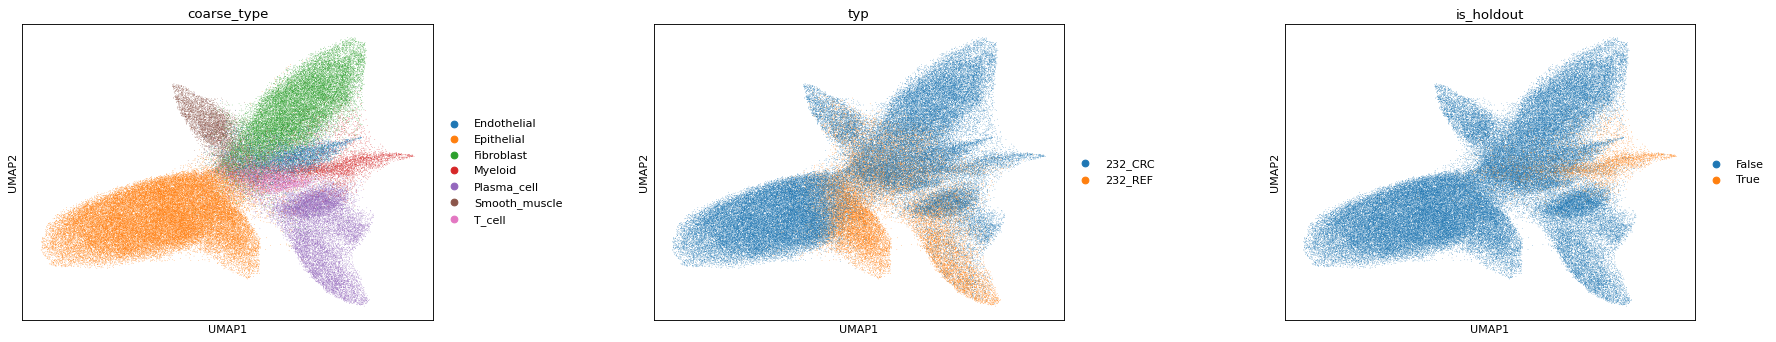

In [23]:
sc.pl.umap(adata, color=[labels_key, domains_key, 'is_holdout'], wspace=0.4)

In [22]:
sc.pp.neighbors(adata, use_rep='cellina_spatial')
sc.tl.umap(adata)

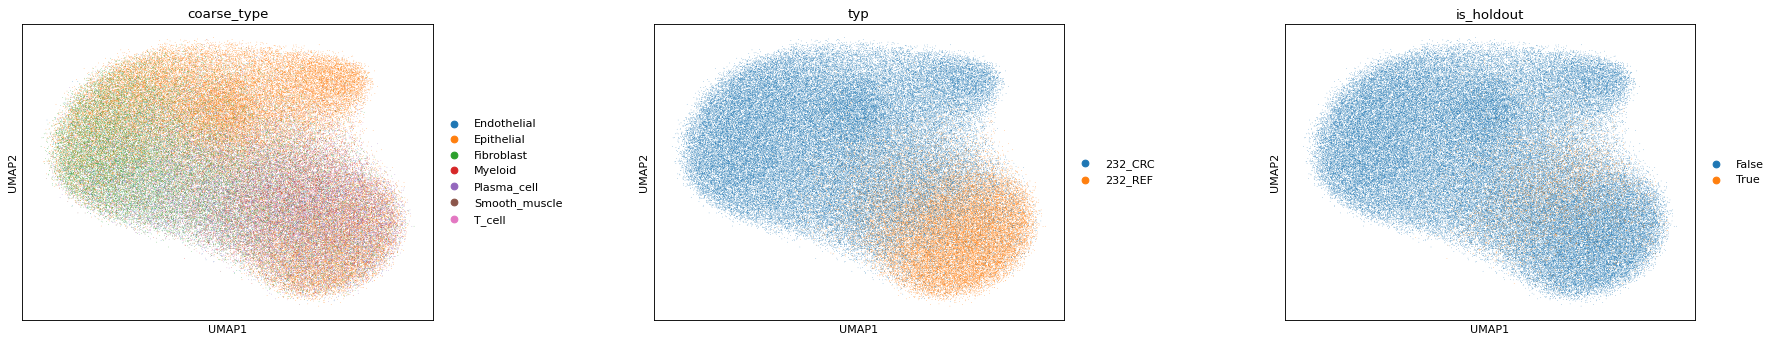

In [23]:
sc.pl.umap(adata, color=[labels_key, domains_key, 'is_holdout'], wspace=0.4)

## 4. Counterfactuals

A tissue-graph counterfactual asks: *what would a cell express if its neighbourhood context changed, while its intrinsic identity stayed fixed?* The spatial graph $\mathcal{G}$ has two mutable parts — its **edges** (neighbourhood topology) and its **node features** (neighbour expression) — giving two perturbation types, both applied **post-training**:

- **Edge perturbation** modifies a cell's neighbours $\mathcal{N}(v)$.
- **Node perturbation** modifies the gene features $\{x_u : u \in \mathcal{N}(v)\}$ of fixed neighbours.

In both cases we evaluate on the **held-out cancer Myeloids**: cells whose true tumour-context expression the model never saw during training. We compare the *observed* healthy→cancer log-fold change (ground truth) against the *predicted* one (counterfactual).

### 4.1 Edge perturbation

**Edge perturbation** (Definition 1) intervenes on a cell's neighbourhood, $\mathcal{N}(v) := \mathcal{N}'$ — neighbours may be added, removed, or replaced.

Here we evaluate it as a **domain edge-rewiring**. Let $\mathcal{I}_y$ be the focal cells of type $y$ (Myeloid) in the **source** domain (healthy, `REF`), and let $\mathcal{P}_{\setminus y}$ be the cells in the **target** domain (cancer, `CRC`) observed as neighbours of type-$y$ cells there — *excluding type $y$ itself*, which keeps the counterfactual conservative. For each focal cell $v \in \mathcal{I}_y$ we sample new neighbours $\mathcal{N}' \sim \mathcal{P}_{\setminus y}$ and set $\mathcal{N}(v) := \mathcal{N}'$. Since the cancer Myeloids were held out of the training graph, this tests whether `Cellina` can predict how a healthy Myeloid would shift if placed in a tumour microenvironment it never saw.

First, we get indices of *control* and *target* cells. *Control* cells are Myeloids that we have seen during training (in the healthy region),
and *target* cells are Myeloids in the cancer region that were held-out during training.
We call these *target* cells because we want to apply in-silico perturbations to *control* cells to look like *target* cells.

In [24]:
is_control_region = adata.obs[domains_key].str.contains('REF')
mask_control = is_control_region & is_holdout_ct
idx_control = np.where(mask_control.values)[0]

mask_target = is_tumor_region & is_holdout_ct
idx_target = np.where(mask_target.values)[0]

Now, we want to get the indices of cells from which to sample new neighbouring cells for healthy Myeloids i.e. the set of observed neighbours of cancer Myeloids ($\mathcal{P}_{\setminus y}$, excluding Myeloids themselves).

In [25]:
# "neighbour_indices" are indices of the neighbors of idx_target cells
conn = adata.obsp["spatial_connectivities_orig"]
sub_conn = conn[idx_target]                # rows for target cells
neighbor_indices = sub_conn.nonzero()[1]   # all neighbors at once
neighbor_indices = np.unique(neighbor_indices)
# remove neighbors having same ct as holdout_ct
neighbor_indices = neighbor_indices[~is_holdout_ct.values[neighbor_indices]]

`get_counterfactual_expression` rewires each control cell's neighbourhood by sampling from `neighbour_indices` and decodes the new expression. (`precomputed=False` recomputes the aggregated spatial features $\varphi(v)$ from the sampled neighbours.)

In [26]:
args_gex = {
    "indices": idx_control,
    "batch_size": 2048,
    "seed": 0,
    "neighbour_indices": neighbor_indices,
    "precomputed": False,
}

counterfactual_counts = model.get_counterfactual_expression(**args_gex)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [27]:
def _normalize_counts(x, eps=1e-8, scale=1e4):
    return x / (x.sum(axis=1, keepdims=True) + eps) * scale

def safe_log2_fold_change(a, b, eps=1e-6):
    """
    Compute log2((a + eps) / (b + eps)) elementwise.
    Use this instead of log2(a - b). eps should be set relative to normalized scale.
    """
    a = np.asarray(a)
    b = np.asarray(b)
    return np.log2((a + eps) / (b + eps))

def get_lfc(control, target, counterfactual, normalize_counts=True, n_deg=200):
    if normalize_counts:
        control = _normalize_counts(control)
        target = _normalize_counts(target)
        counterfactual = _normalize_counts(counterfactual)

    mean_control = np.nanmean(control, axis=0)
    mean_target = np.nanmean(target, axis=0)
    mean_cf = np.nanmean(counterfactual, axis=0)

    # compute log2 fold changes
    gt_vec = safe_log2_fold_change(mean_target, mean_control)
    cf_vec = safe_log2_fold_change(mean_cf, mean_control)

    deg_scores = np.abs(gt_vec)
    top_features = np.argsort(-deg_scores)[:n_deg]

    return gt_vec, cf_vec, top_features

Finally, we compare the ground-truth log-fold change (healthy vs. cancer Myeloids) against the counterfactual one (healthy vs. edge-perturbed Myeloids). We highlight the top differentially-expressed genes (largest $|$observed logFC$|$) and report Pearson's $r$ over them.

In [28]:
control = np.array(adata.layers['counts'][mask_control.values, :].todense())
target = np.array(adata.layers['counts'][mask_target.values, :].todense())
counterfactual = counterfactual_counts

true_lfc, pred_lfc, deg = get_lfc(control=control, target=target, counterfactual=counterfactual, n_deg=50)

In [37]:
pearson, _ = pearsonr(true_lfc[deg], pred_lfc[deg])

As we see, `Cellina` transforms healthy Myeloid cells into cancer-like Myeloids purely by swapping their neighbours — recovering the observed direction and magnitude of the top gene changes.

In [30]:
from adjustText import adjust_text


def plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson):
    """Scatter of observed vs. predicted logFC, highlighting the top DE genes.

    Top genes are coloured by the direction of the *observed* change and their
    names are repelled with adjustText so the labels stay legible.
    """
    fig, ax = plt.subplots(figsize=(6, 5.5))

    deg = np.asarray(deg)
    non_deg = np.setdiff1d(np.arange(len(true_lfc)), deg)

    # background (non-DE) genes
    ax.scatter(true_lfc[non_deg], pred_lfc[non_deg],
               alpha=0.25, s=8, color="lightgray", linewidths=0, rasterized=True)

    # top DE genes, coloured by the direction of the observed change
    up = deg[true_lfc[deg] >= 0]
    down = deg[true_lfc[deg] < 0]
    ax.scatter(true_lfc[up], pred_lfc[up], s=45, color="#d62728",
               edgecolor="white", linewidths=0.5, zorder=3, label="up in cancer")
    ax.scatter(true_lfc[down], pred_lfc[down], s=45, color="#1f77b4",
               edgecolor="white", linewidths=0.5, zorder=3, label="down in cancer")

    # repelled gene labels
    texts = [ax.text(true_lfc[i], pred_lfc[i], gene_names[i], fontsize=8) for i in deg]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.6", lw=0.5))

    # identity line
    lo = float(min(true_lfc.min(), pred_lfc.min()))
    hi = float(max(true_lfc.max(), pred_lfc.max()))
    pad = 0.05 * (hi - lo)
    lims = [lo - pad, hi + pad]
    ax.plot(lims, lims, "k--", lw=1, alpha=0.6, zorder=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")

    ax.set_xlabel("Observed logFC  (control → cancer)")
    ax.set_ylabel("Predicted logFC  (counterfactual)")
    ax.set_title(f"{holdout_ct}: observed vs. predicted logFC   (Pearson r = {pearson:.2f})")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    fig.tight_layout()
    plt.show()

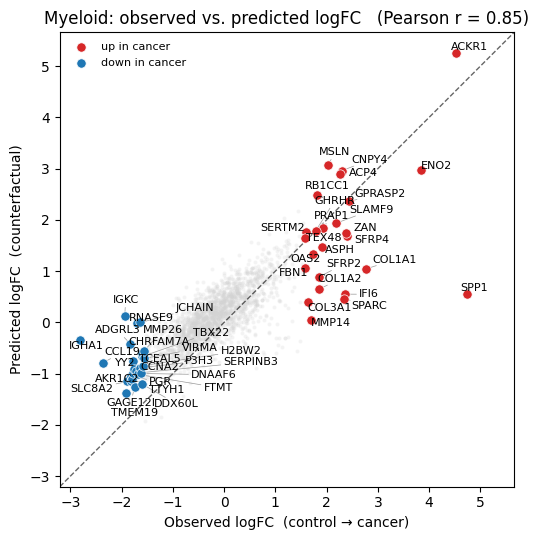

In [31]:
gene_names = np.array(adata.var_names)

plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson)

### 4.2 Node perturbation

**Node perturbation** (Definition 2) keeps the graph topology fixed but edits the neighbours' feature vectors. For a target gene set $\mathcal{S}$,

$$x_{u,g}^{\mathrm{cf}} = \begin{cases} T_g(x_{u,g}) & g \in \mathcal{S} \\ x_{u,g} & g \notin \mathcal{S}. \end{cases}$$

The transformation $T_g$ is arbitrary (knockout, overexpression, an additive shift, …); restricting it to a gene set $\mathcal{S}$ is biologically motivated, since genes act in co-regulated programs (a pathway or regulon). Biologically, this mimics an intervention — e.g. a CRISPR perturbation — applied to the neighbouring cells. Here we instantiate $T_g$ as the **observed healthy→cancer log-fold change** of the top-$n$ genes, estimated **per cell type** by pseudobulk. Crucially, the held-out Myeloid population is shifted by the *global* (cell-type-averaged) change rather than its own, so the model never sees the true Myeloid perturbation it is asked to predict.

In [32]:
n_pert_genes = 200
control_domain = '232_REF'
target_domain = '232_CRC'

Here we define helper functions to compute the perturbation logFC (global and cell-type-specific) from pseudobulk profiles, using `decoupler` {cite:p}`badia2022decoupler`.

In [33]:
import pandas as pd
import scipy.sparse as sp
import decoupler as dc

def get_perturbation_logfc(adata, control_domain, holdout_domain, labels_key, domains_key):
    # Cell-type-specific
    pdata_ct = dc.pp.pseudobulk(
        adata=adata, sample_col=domains_key, groups_col=labels_key, mode='sum', layer='counts'
    )
    sc.pp.normalize_total(pdata_ct, target_sum=1e4)
    sc.pp.log1p(pdata_ct)

    cell_types_with_both = [
        ct for ct in pdata_ct.obs[labels_key].unique()
        if ((pdata_ct.obs[domains_key] == control_domain) & (pdata_ct.obs[labels_key] == ct)).any()
        and ((pdata_ct.obs[domains_key] == holdout_domain) & (pdata_ct.obs[labels_key] == ct)).any()
    ]

    _ct_rows = []
    for _ct in cell_types_with_both:
        _crc_ct = pdata_ct[(pdata_ct.obs[domains_key] == holdout_domain) & (pdata_ct.obs[labels_key] == _ct)].X
        _ref_ct = pdata_ct[(pdata_ct.obs[domains_key] == control_domain) & (pdata_ct.obs[labels_key] == _ct)].X
        _crc_m  = np.asarray(_crc_ct.mean(axis=0)).flatten() if sp.issparse(_crc_ct) else _crc_ct.mean(axis=0).flatten()
        _ref_m  = np.asarray(_ref_ct.mean(axis=0)).flatten() if sp.issparse(_ref_ct) else _ref_ct.mean(axis=0).flatten()
        _ct_rows.append(pd.Series(_crc_m - _ref_m, index=pdata_ct.var_names, name=_ct))
    domain_logfc_df = pd.concat(_ct_rows, axis=1).T

    return domain_logfc_df


def get_global_perturbation_logfc(adata, control_domain, holdout_domain, labels_key, domains_key, holdout_ct):
    adata_sub = adata[adata.obs[labels_key]!=holdout_ct]
    pdata_global = dc.pp.pseudobulk(
        adata=adata_sub, sample_col=domains_key, groups_col=None, mode='sum', layer='counts'
    )
    sc.pp.normalize_total(pdata_global, target_sum=1e4)
    sc.pp.log1p(pdata_global)

    _holdout_X    = pdata_global[pdata_global.obs[domains_key] == holdout_domain].X
    _control_X    = pdata_global[pdata_global.obs[domains_key] == control_domain].X
    _holdout_mean = np.asarray(_holdout_X.mean(axis=0)).flatten() if sp.issparse(_holdout_X) else _holdout_X.mean(axis=0).flatten()
    _control_mean = np.asarray(_control_X.mean(axis=0)).flatten() if sp.issparse(_control_X) else _control_X.mean(axis=0).flatten()

    return pd.Series(_holdout_mean - _control_mean, index=pdata_global.var_names)

In [34]:
# Cell-type-specific perturbation
domain_logfc_df = get_perturbation_logfc(adata, control_domain, target_domain, labels_key, domains_key)
global_logfc_series = get_global_perturbation_logfc(adata, control_domain, target_domain, labels_key, domains_key, holdout_ct)
domain_logfc_df.loc[holdout_ct, global_logfc_series.index] = global_logfc_series # NOTE: set the holdout celltype's perturbation to the global perturbation - ct

logfc_series_dict = {}
for ct in domain_logfc_df.index:
    s = domain_logfc_df.loc[ct]
    top_g = s.abs().nlargest(n_pert_genes).index.tolist()
    logfc_series_dict[ct] = s[top_g]

For base `Cellina`, the shift is applied additively in log-space on the **aggregated** neighbour features (`make_neighbor_perturbation`, `add_shift=True`), then re-aggregated into the spatial features $\varphi(v)$ before inference. (For the `Cellina-GAT` variant, the shift is instead applied to each neighbour cell individually via `make_perturbed_expression` and a `cf_layer`, and aggregated by the GAT on the fly.)

In [35]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

make_neighbor_perturbation(
        adata,
        perturbations=logfc_series_dict,
        groupby=labels_key,
        obsm_key_out='spatial_x_cf',
        base=np.e,
        renormalize=True,
        add_shift=True,
)
pert_expr = model.get_perturbed_expression(
    adata=adata, indices=idx_control, spatial_obsm_key='spatial_x_cf',
    batch_size=2048, library_size=1e4,
)

In [36]:
control = np.array(adata.layers['counts'][mask_control.values, :].todense())
target = np.array(adata.layers['counts'][mask_target.values, :].todense())
counterfactual = pert_expr

true_lfc, pred_lfc, deg = get_lfc(control=control, target=target, counterfactual=counterfactual, n_deg=20)

In [37]:
pearson, _ = pearsonr(true_lfc[deg], pred_lfc[deg])

Once again, `Cellina` predicts the effect of the neighbouring gene modifications on the held-out Myeloid population.

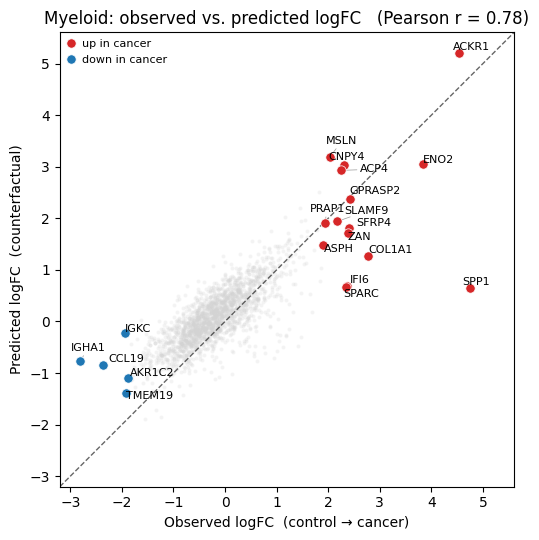

In [38]:
plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson)

## References

```{bibliography}
:filter: docname in docnames
```